#### Unsupervised Learning: Take-Home Assignment

#### Section A: Output Prediction 

#### A1.  K-Means by hand   

#### Prediction Before Running The Code

####  A1(a) Prediction Output of Line 1: (labels_)

The data points are:

[1, 2, 3, 10, 11, 12]

The initial cluster centres are:

[1, 2]

There are 2 clusters.

Predicted output of line 1

I predict:

[0 0 0 1 1 1] Because the first three values (1, 2, 3) are close to each other, while 10, 11 and 12 form another group. Therefore, the first three points should belong to one cluster and the last three points should belong to the other cluster.

The labels are represented by 0 and 1.

#### A1(b) Prediction  output of line 2(cluster_centers_)

I predict:

[ 2. 11.]

After clustering, the first cluster contains:

1, 2, 3

Its centre is:

(1 + 2 + 3) / 3 = 2

The second cluster contains:

10, 11, 12

Its centre is:

(10 + 11 + 12) / 3 = 11

Therefore, the final cluster centres should be 2 and 11.


#### A1(c) Prediction Output Of Line 3 (inertia_) 

I predict:4.0

Because K-Means inertia is the sum of squared distances of every point from its cluster centre.

For the first cluster:
(1 - 2)^2 + (2 - 2)^2 + (3 - 2)^2
= 1 + 0 + 1
= 2

For the second cluster:
(10 - 11)^2 + (11 - 11)^2 + (12 - 11)^2
= 1 + 0 + 1
= 2
Total inertia:
2 + 2 = 4

Therefore, the predicted inertia is 4.0.




#### A1(d) First two assign-and-update iterations

Initial centres:

[1, 2]

#### Iteration 1 

Using centres 1 and 2:

- 1 is closest to centre 1
- 2 is closest to centre 2
- 3 is closest to centre 2
- 10, 11 and 12 are also closest to centre 2

So the first assignment is:

[0, 1, 1, 1, 1, 1]

Update the centres:

Cluster 0:
1
Cluster 1:
2, 3, 10, 11, 12
New centre of cluster 0:
1
New centre of cluster 1:
(2 + 3 + 10 + 11 + 12) / 5 = 7.6
So after the first update:[1.0, 7.6]

#### Iteration 2 

Using centres 1 and 7.6:

- 1, 2 and 3 are closer to 1
- 10, 11 and 12 are closer to 7.6

Therefore:

[0, 0, 0, 1, 1, 1]

New centres:

Cluster 0:(1 + 2 + 3) / 3 = 2

Cluster 1:(10 + 11 + 12) / 3 = 11

So after the second update:[2.0, 11.0]

The assignments are now stable, so K-Means stops.

In [1]:
import numpy as np
from sklearn.cluster import KMeans

X = np.array([[1], [2], [3], [10], [11], [12]])

init = np.array([[1.0], [2.0]])

km = KMeans(
    n_clusters=2,
    init=init,
    n_init=1
).fit(X)

print(km.labels_)
print(km.cluster_centers_.ravel())
print(km.inertia_)

[0 0 0 1 1 1]
[ 2. 11.]
4.0


#### Actual output after running the code

[0 0 0 1 1 1]

[ 2. 11.]

4.0



#### A2. PCA on Correlated Data

#### A2(a). Prediction Of Line1

The data is : X = [[1, 2],[2, 4],[3, 6],[4, 8]]

The two features are perfectly correlated because the second feature is always
2 times the first feature.

PCA reduces the two features into one principal component.

I predict:[1.]

Because both features contain the same underlying pattern because the second feature
is exactly twice the first feature. Therefore, one principal component can
capture all the variation in the data.

So I expect the explained variance ratio to be 1.0, meaning 100% of the variance is explained by the first component.


#### A2(b) Prediction for line 2

I predict:

[3.35 1.12 1.12 3.35]

Because first PCA centres the data by subtracting the mean of each column.

Mean of the first column:

(1 + 2 + 3 + 4) / 4 = 2.5

Mean of the second column:

(2 + 4 + 6 + 8) / 4 = 5

After centring:

[-1.5, -3]
[-0.5, -1]
[ 0.5,  1]
[ 1.5,  3]

The two columns still contain the same information.
PCA projects these centred points onto the main direction of the data.
The projected values have magnitudes approximately:
3.35, 1.12, 1.12, 3.35
Since np.abs() is used, the negative signs are removed.
So the predicted output is:
[3.35 1.12 1.12 3.35]


#### A2(c) Prediction for lines 3 and 4

Line 3:

(4, 1)

Line 4:

False

Reason for line 3:

There are 4 rows in the original data and PCA keeps only 1 component.Therefore, Z has 4 rows and 1 column.

Reason for line 4:

The PCA result has only one component, so some information from the original two columns is lost. Therefore, I expect inverse_transform()
not to reproduce the original X exactly.


#### (d) Why is np.abs() used?

np.abs() is used to remove negative signs from the PCA values.

Without np.abs(), the values could contain negative numbers, which may
make the output look different even though the PCA result is correct.
The reviewer should be careful about this because PCA directions can
have different signs.

In [2]:
import numpy as np
from sklearn.decomposition import PCA

X = np.array([[1, 2], [2, 4], [3, 6], [4, 8]], dtype=float)

pca = PCA(n_components=1).fit(X)

Z = pca.transform(X)

print(pca.explained_variance_ratio_)
print(np.abs(Z).ravel().round(2))
print(Z.shape)
print(np.allclose(pca.inverse_transform(Z), X))

[1.]
[3.35 1.12 1.12 3.35]
(4, 1)
True


Actual Output:
[1.]

[3.35 1.12 1.12 3.35]

(4, 1)

True

Predicted Output:
[1.]

[3.35 1.12 1.12 3.35]

(4, 1)

False

My prediction was False because I expected that reducing two dimensions to one PCA component would lose some information. However, the actual output was True. The reason is that the two original features are perfectly correlated: the second feature is always two times the first feature. Therefore, one principal component contains all the information needed to reconstruct the original data. Hence inverse_transform() reproduces X closely and np.allclose() returns True.

#### Section B: Code Refactoring 

## B1.  Customer segmentation script   

### Refactored Code

In [3]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv(r"C:\Calibo\Unsupervised_Assignment\cleaned_customer_dataset")

# Features
features = ["Annual_Income", "Spending_Score", "Age"]

# Select features
X = df[features]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find the best number of clusters
silhouette_scores = {}

for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores[k] = score

# Select best k
best_k = max(silhouette_scores, key=silhouette_scores.get)

# Final K-Means model
model = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42
)

df["cluster"] = model.fit_predict(X_scaled)

# Cluster profile
cluster_profile = df.groupby("cluster")[features].mean()

# Results
print("Best number of clusters:", best_k)

print("\nSilhouette Scores:")
for k, score in silhouette_scores.items():
    print(k, ":", score)

print("\nCluster Profile:")
print(cluster_profile)

Best number of clusters: 5

Silhouette Scores:
2 : 0.22264798711362307
3 : 0.2351389134056244
4 : 0.25036229199441234
5 : 0.2581618703576263

Cluster Profile:
         Annual_Income  Spending_Score        Age
cluster                                          
0         50336.956522       39.065217  28.130435
1         89056.521739       44.978261  34.521739
2         70603.703704       27.259259  46.777778
3         60038.888889       79.944444  32.277778
4         54297.674419       54.581395  42.093023


### Changed Log

1.Removed duplication: Used a feature list and a loop to calculate the silhouette score for different values of k instead of writing separate code for k = 2, 3, 4 and 5.

2.Used StandardScaler: Replaced the manual scaling calculations with scikit-learn's StandardScaler, making the preprocessing cleaner and easier to reuse.

3.Made the code reproducible: Added random_state=42 to K-Means so that the clustering results can be reproduced when the code is run again.

4.Made the feature list and k-range configurable: The features are stored in features and the values of k are stored in k_range, so they can be changed easily without modifying the main code.

5.Created the cluster profile in one step: Used one groupby() statement with the feature list to calculate the average Annual_Income, Spending_Score, and Age for each cluster.

## B2.  Dimensionality reduction helper   

In [4]:
import numpy as np
from sklearn.decomposition import PCA
 
def reduce(train, test):
    mu = test.mean(axis=0)
    sd = test.std(axis=0)
    train = (train - train.mean(axis=0)) / train.std(axis=0)
    test = (test - mu) / sd
    best = None
    for n in range(1, train.shape[1] + 1):
        p = PCA(n_components=n).fit(train)
        if sum(p.explained_variance_ratio_) >= 0.90:
            best = n
            break
    p = PCA(n_components=best).fit(train)
    return p.transform(train), p.transform(test)


## B2(a)  Problems in the original code

1.Data leakage: The test data is used to calculate mu and sd, which means information from the test set is used during preprocessing.

2.Different scaling methods: The training data uses its own mean and standard deviation, while the test data uses the test mean and standard deviation. Both should use the statistics learned from the training data.

3.Repeated PCA fitting: PCA is fitted once for every possible number of components and then fitted again after finding best. This makes the code less efficient.

4.Fixed variance target: The value 0.90 is written directly inside the function, so it cannot be easily changed.

## B2(b) Refactored code

In [5]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def reduce(train, test, variance_target=0.90):

    # Scale using only training data
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # Fit PCA once
    pca = PCA()
    pca.fit(train_scaled)

    # Find the minimum number of components
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    best = np.argmax(cumulative_variance >= variance_target) + 1

    # Transform train and test data
    pca = PCA(n_components=best)
    train_reduced = pca.fit_transform(train_scaled)
    test_reduced = pca.transform(test_scaled)

    return train_reduced, test_reduced

## B2(c)

In [6]:
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def reduce(train, test, variance_target=0.90):
    """
    Scale the data and reduce its dimensions using PCA.

    Keeps the smallest number of components that explains
    the required amount of variance.
    """

    # Scale the data using only training data
    scaler = StandardScaler()

    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # Fit PCA on training data
    pca = PCA()
    pca.fit(train_scaled)

    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(
        pca.explained_variance_ratio_
    )

    # Find the smallest number of components
    best = np.argmax(
        cumulative_variance >= variance_target
    ) + 1

    # Create PCA with the selected number of components
    pca = PCA(n_components=best)

    # Transform training and test data
    train_reduced = pca.fit_transform(train_scaled)
    test_reduced = pca.transform(test_scaled)

    # Return reduced datasets
    return train_reduced, test_reduced

## Change Log
Fixed data leakage: Used only the training data to calculate scaling values.

Used StandardScaler: Replaced manual scaling with StandardScaler.

Improved efficiency: PCA is fitted once to find the required number of components.

Made the variance target configurable: Added variance_target=0.90, so the required variance can be changed easily.

## Section C: Scenario-Based Questions

## C1. Bank Customer Segmentation

## C1(a) Preprocessing plan

First, I would check the data for missing values, incorrect values, duplicates, and unusual values.

Missing credit-card spend: Since about 8% of customers have missing values, I would not simply remove those customers. I would fill the missing values using a suitable method such as the median, because credit-card spend can be affected by very high-spending customers.

Very high balances: About 0.3% of customers have balances 50–100× the median. I would investigate these values first rather than deleting them automatically, because they may be genuine high-value customers. A log transformation or robust scaling can reduce their effect on clustering.

Numerical features: Average monthly balance, transactions per month, number of products, tenure, and credit-card spend should be scaled so that features with larger numerical values do not dominate the distance calculations.

Preferred channel: Branch, mobile, and web are categorical values, so I would convert them into numerical form using one-hot encoding.
Finally, I would check the processed data again before applying a clustering algorithm.

## C1(b) Deciding the number of segments

Although Marketing requested five segments, I would not select five only because it was requested.

I would compare different values of k, including 5, using quantitative measures such as:

Silhouette score: A higher score means customers within a cluster are more similar and customers in different clusters are more different.

Calinski–Harabasz score: A higher score generally indicates better-separated and more compact clusters.

## C1(c) Checking stability and usefulness

I would run the clustering multiple times with different random starting points or samples and check whether similar customer groups are produced. I would also compare the cluster sizes and their feature averages.

## C2 Clustering support-ticket embeddings   

### C2(a) Critique with the proposed plan

I would not directly use t-SNE for clustering because:

1.t-SNE is mainly used for visualization, not for finding the final clusters.

2.Reducing 768 dimensions to only 2 can lose useful information from the ticket embeddings.

3.K-Means on the 2D t-SNE output may create clusters that are not actually present in the original data.

4.With 50,000 tickets, running t-SNE can also take a lot of time.






## C2(b) Improved Pipeline 

1. Preprocessing: Remove duplicates (cosine similarity > 0.99)

2. Dimensionality Reduction:
   - PCA → 50D (capture 95%+ variance, remove noise, fast)
   - Optional UMAP → 10D (balance local + global structure)

3. Clustering (choose one):
   - HDBSCAN (recommended): Density-based, finds elongated clusters, no fixed k
   - K-Means: Fit on 50D space (NOT 2D), use silhouette score to choose k

4. Visualization:
   - Use t-SNE/UMAP → 2D only for human exploration
   - Cluster in full space, then visualize
   - Never cluster on visualization

### C2(c) Checking whether the clusters are meaningful

I would check the silhouette score to see whether the clusters are reasonably separated.

Then, I would look at some actual support tickets from each cluster. If the tickets in the same cluster talk about similar problems, the cluster can be considered a meaningful theme.

I would also ask the support team to review the clusters and confirm whether the identified themes make sense.

### Section D Edge Case Questions 

## D1. Clustering under unusual conditions   

## D1(a) Duplicate points with too many clusters requested

Prediction:
K-Means will give a ConvergenceWarning because there are only 2 unique points, but we requested 3 clusters.

K-Means will run, but it will produce a ConvergenceWarning saying that the number of distinct clusters found is smaller than the number of requested clusters.


In [7]:
import warnings
X = np.array([
    [1, 1],
    [1, 1],
    [2, 2],
    [2, 2]
], dtype=float)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")

    km = KMeans(
        n_clusters=3,
        n_init=10,
        random_state=0
    ).fit(X)

print("Labels:", km.labels_)
print("Cluster Centers:")
print(km.cluster_centers_)
print("Inertia:", km.inertia_)

for warning in w:
    print("Warning:", warning.message)

Labels: [1 1 0 0]
Cluster Centers:
[[2. 2.]
 [1. 1.]
 [2. 2.]]
Inertia: 0.0


## Actual Behaviour

When the code is run, K-Means does not give a fatal error. It runs, but it gives a ConvergenceWarning similar to:

ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3).
Possibly due to duplicate points in X.

So, even though we requested 3 clusters, K-Means finds only 2 distinct clusters.

### Why?

Why?

The dataset is:[1, 1][1, 1][2, 2][2, 2]

There are 4 rows, but only 2 unique points:
[1, 1][2, 2]

The duplicate points do not create new locations. Therefore, K-Means can only find 2 distinct groups, not 3.

So the warning appears because:

Requested clusters = 3
Available unique points = 2

K-Means still completes, but one of the requested clusters cannot become a separate distinct cluster.

## D1(b) A zero-variance feature

The manual z-score will produce NaN values for the second column because it divides by a standard deviation of 0.StandardScaler will handle the constant column safely and convert it to 0.K-Means using the manual scaled data will not work properly because the input contains NaN.K-Means using the StandardScaler output will work normally.


In [8]:
X = np.array([
    [1, 5],
    [2, 5],
    [3, 5]
], dtype=float)

manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

sk = StandardScaler().fit_transform(X)

print("Manual:")
print(manual)

print("\nStandardScaler:")
print(sk)

Manual:
[[-1. nan]
 [ 0. nan]
 [ 1. nan]]

StandardScaler:
[[-1.22474487  0.        ]
 [ 0.          0.        ]
 [ 1.22474487  0.        ]]


C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_2876\3530042811.py:7: RuntimeWarning: invalid value encountered in divide
  manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)


### Comparison: Manual Z-score vs StandardScaler

The **manual z-score** produces NaN for the second column because that column has zero variance. The calculation divides by zero.

```text
Manual:
[[-1. nan]
 [ 0. nan]
 [ 1. nan]]
 Because of the NaN values, K-Means gives an error.
StandardScaler handles the zero-variance column safely and converts it to 0.
StandardScaler:
[[-1.2247  0.    ]
 [ 0.      0.    ]
 [ 1.2247  0.    ]] K-Means can run successfully with the StandardScaler output

Why?
The second feature is constant, so its standard deviation is 0. The manual formula divides by 0, while StandardScaler safely handles the zero-variance feature.

## D2(c) Non-spherical clusters

## Prediction:

K-Means performs poorly on the moon-shaped data because it expects round clusters, while DBSCAN performs very well because it can identify clusters based on density and shape

In [9]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

X, y_true = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=0
)

km_labels = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=0
).fit_predict(X)

db_labels = DBSCAN(
    eps=0.2
).fit_predict(X)

print("K-Means :",
      adjusted_rand_score(y_true, km_labels))

print("DBSCAN :",
      adjusted_rand_score(y_true, db_labels))

K-Means : 0.24083922992439677
DBSCAN : 1.0


K-Means: Gives a low ARI score of about 0.24 because K-Means assumes clusters are roughly spherical/round and separates them based on distance from cluster centers. The moon-shaped clusters do not fit this assumption.

DBSCAN: Gives an ARI of 1.0, which means it identified the two moon-shaped clusters correctly. DBSCAN groups points based on density and nearby points, so it can handle non-spherical shapes.

## D1(d)  List at least two automatic checks you would add to a production pipeline to flag a K-Means result that should not be trusted.

Two checks I would add to a production pipeline are:

1.Silhouette Score – If the score is too low, the clusters are not well separated, so the result may not be reliable.

2.Cluster size check – If one cluster contains almost all customers and another contains very few, the clustering may not be useful or trustworthy.

### D2.  Dimensionality reduction under unusual conditions   

## D2(a) More components requested than the data allows

Prediction

Before running the code, I predict that PCA will give an 
"ValueError"

Because  there are only 5 samples and 20 features, but we are asking for 10 components.

In [10]:
import numpy as np
from sklearn.decomposition import PCA

X = np.random.RandomState(0).rand(5, 20)

pca = PCA(n_components=5)
pca.fit(X)

print("PCA fitted successfully")
print("Number of components:", pca.n_components_)

PCA fitted successfully
Number of components: 5


### Why this happens?

The data has:
5 samples
20 features
Requested components = 10
But PCA cannot create more components than the smaller dimension.
Maximum components = min(5, 20)
                   = 5
So:
Requested = 10
Allowed   = 5

Hence, PCA(n_components=10) raises a ValueError.

## Rule for the maximum number of components

min(number of samples, number of features)

Samples = 5

Features = 20

So:
min(5, 20) = 5

Therefore, the maximum number of components is 5.

## D2(b)Missing values

Prediction

I predict that PCA will give a ValueError because the input contains a NaN value.

In [11]:
import numpy as np
from sklearn.decomposition import PCA

X = np.random.RandomState(0).rand(10, 3)
X[0, 0] = np.nan

try:
    PCA(n_components=2).fit(X)
except ValueError as e:
    print(f" Error: {e}")
    # Output: Input contains NaN, infinity or a value too large

 Error: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values


### Why This Fails:
PCA computes covariance matrix: cov = X.T @ X / n
NaN values propagate through matrix operations, contaminating the covariance
scikit-learn explicitly checks for NaN/inf values and raises an error

## D2 (c) Degenerate data

Prediction

When all values are identical (all ones), the data has zero variance. PCA will produce zero explained variance ratios because there is no variation in the data for the principal components to explain.

In [12]:
PCA(n_components=2).fit(np.ones((6, 3))).explained_variance_ratio_


c:\Users\KEERTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


array([nan, nan])

It prints array([nan, nan]) (with a possible runtime warning). This happens because all values are constant, so every feature has zero variance and the total variance is zero. The explained variance ratio therefore involves division by zero, producing NaN. I would guard against this by checking for zero-variance features before PCA and removing them or skipping PCA if no variable features remain.

## D2 (d) Features on very different scales

Prediction

Without standardisation, PCA will be strongly influenced by the second feature because its values are 1000 times larger. After standardisation, both features will have a similar influence, so the explained variance will be more balanced.

In [13]:
rng = np.random.RandomState(0)
A = np.c_[rng.normal(0, 1, 200),          # feature 1: small units
          rng.normal(0, 1, 200) * 1000]   # feature 2: same spread, 1000x units
 
PCA().fit(A).explained_variance_ratio_
PCA().fit(StandardScaler().fit_transform(A)).explained_variance_ratio_



array([0.53780576, 0.46219424])

In [14]:
PCA().fit(A).explained_variance_ratio_

array([9.99998834e-01, 1.16589485e-06])

Interpretation

Without standardisation, the second feature has values that are 1000 times larger than the first feature. Therefore, PCA is strongly influenced by the scale of the second feature, and the first principal component explains almost all the variance: 99.9998834%.

After applying StandardScaler, both features are brought to the same scale. The explained variance becomes much more balanced, with the first component explaining 53.78% and the second component explaining 46.22%.

This shows that when features have very different scales or units, we should standardise the data before applying PCA. Otherwise, a large-scale feature can dominate the PCA results simply because of its units, not because it contains more useful information.

### Section E: Design Challenge 

## E1. Problem Framing and Feature Design

Business Objective:

The main objective is to divide e-commerce customers into meaningful groups based on their spending, ordering behaviour, return behaviour, tenure, and preferred channel. These segments can help the company create more targeted retention campaigns instead of using the same campaign for every customer. The dataset contains 1,500 customers and the actual number of groups is not given.

Feature Selection:

I will use monthly_spend, orders_per_month, return_rate, tenure_months, and preferred_channel for segmentation. customer_id will be dropped because it is only an identifier and does not describe customer behaviour.

monthly_spend may contain large differences between customers. I will check its distribution before clustering. If it is strongly right-skewed, a log transformation can be considered to reduce the effect of very large spending values.

preferred_channel contains categories such as web, app, and store. I will convert this categorical feature into numerical form using One-Hot Encoding so that it can be included in the clustering process.


The numerical features have different units and ranges, so I will use StandardScaler before clustering. This prevents a feature with larger numerical values from dominating the distance calculations.


In [15]:
import numpy as np
import pandas as pd

def make_customers(n=1500, seed=42):
    rng = np.random.default_rng(seed)

    seg = rng.choice(
        4,
        size=n,
        p=[0.40, 0.30, 0.20, 0.10]
    )

    # (monthly_spend, orders_per_month, return_rate)
    spec = {
        0: (300, 6, 0.30),
        1: (900, 14, 0.10),
        2: (2500, 30, 0.05),
        3: (6000, 12, 0.02)
    }

    spend = np.array([
        max(5, rng.normal(spec[s][0], spec[s][0] * 0.25))
        for s in seg
    ])

    orders = np.array([
        max(1, rng.poisson(spec[s][1]))
        for s in seg
    ])

    ret = np.array([
        min(1, max(0, rng.normal(spec[s][2], 0.05)))
        for s in seg
    ])

    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "monthly_spend": spend.round(2),
        "orders_per_month": orders,
        "return_rate": ret.round(3),
        "tenure_months": rng.integers(1, 60, n),
        "preferred_channel": rng.choice(
            ["web", "app", "store"],
            n,
            p=[0.45, 0.40, 0.15]
        )
    })

    df.loc[
        rng.choice(n, 60, replace=False),
        "monthly_spend"
    ] = np.nan

    return df


df = make_customers()

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

df.head()

Shape: (1500, 6)

Missing values:
customer_id           0
monthly_spend        60
orders_per_month      0
return_rate           0
tenure_months         0
preferred_channel     0
dtype: int64


,customer_id,monthly_spend,orders_per_month,return_rate,tenure_months,preferred_channel
0,1,3101.85,32,0.129,47,app
1,2,736.96,17,0.121,26,app
2,3,1966.40,26,0.031,4,store
3,4,1003.43,15,0.107,22,store
4,5,374.14,11,0.249,6,app


### E2 Pipeline implementation

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [17]:
numeric_features = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months"
]

categorical_features = [
    "preferred_channel"
]

X = df[numeric_features + categorical_features]

In [18]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [19]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=0.90, random_state=42)),
    ("clustering", KMeans(
        n_clusters=4,
        n_init=10,
        random_state=42
    ))
])

In [20]:
pipeline.fit(X)

print("Pipeline fitted successfully")

Pipeline fitted successfully


In [21]:
clusters = pipeline.predict(X)

df["cluster"] = clusters

df.head()

,customer_id,monthly_spend,orders_per_month,return_rate,tenure_months,preferred_channel,cluster
0,1,3101.85,32,0.129,47,app,0
1,2,736.96,17,0.121,26,app,3
2,3,1966.40,26,0.031,4,store,0
3,4,1003.43,15,0.107,22,store,3
4,5,374.14,11,0.249,6,app,3


In [22]:
new_customer = pd.DataFrame({
    "monthly_spend": [1200],
    "orders_per_month": [18],
    "return_rate": [0.08],
    "tenure_months": [24],
    "preferred_channel": ["app"]
})

new_cluster = pipeline.predict(new_customer)

print("New customer segment:", new_cluster[0])

New customer segment: 0


### E3 Model Selection and Validation

In [23]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans
import numpy as np

In [24]:
k_values = range(2, 7)

silhouette_scores = []
calinski_scores = []

for k in k_values:

    pipeline.set_params(
        clustering__n_clusters=k,
        clustering__random_state=42
    )

    X_transformed = pipeline[:-1].fit_transform(df)

    labels = pipeline.named_steps["clustering"].fit_predict(X_transformed)

    silhouette_scores.append(
        silhouette_score(X_transformed, labels)
    )

    calinski_scores.append(
        calinski_harabasz_score(X_transformed, labels)
    )

print("K values:", list(k_values))
print("Silhouette Scores:", silhouette_scores)
print("Calinski-Harabasz Scores:", calinski_scores)

K values: [2, 3, 4, 5, 6]
Silhouette Scores: [0.31264779903829487, 0.26673861077634886, 0.29288638503787373, 0.3052659021264872, 0.3098747303871181]
Calinski-Harabasz Scores: [816.8018803744037, 688.6471243118248, 681.2544191273481, 735.22929693514, 746.7337151001487]


In [25]:
best_k_silhouette = list(k_values)[np.argmax(silhouette_scores)]
best_k_calinski = list(k_values)[np.argmax(calinski_scores)]

print("Best K according to Silhouette Score:", best_k_silhouette)
print("Best K according to Calinski-Harabasz Score:", best_k_calinski)

Best K according to Silhouette Score: 2
Best K according to Calinski-Harabasz Score: 2


In [26]:
seeds = [0, 10, 42, 100, 200]

stability_results = {}

for k in k_values:

    scores = []

    for seed in seeds:

        pipeline.set_params(
            clustering__n_clusters=k,
            clustering__random_state=seed
        )

        X_transformed = pipeline[:-1].fit_transform(df)

        labels = pipeline.named_steps["clustering"].fit_predict(X_transformed)

        score = silhouette_score(X_transformed, labels)
        scores.append(score)

    stability_results[k] = scores

print("Stability results:")
for k, scores in stability_results.items():
    print("K =", k, ":", scores)

Stability results:
K = 2 : [0.31264779903829487, 0.31264779903829487, 0.31264779903829487, 0.31264779903829487, 0.3127298222132824]
K = 3 : [0.32961468064590926, 0.26673861077634886, 0.26673861077634886, 0.32963079353342917, 0.3296033214155779]
K = 4 : [0.31608999001178617, 0.31608999001178617, 0.29288638503787373, 0.31611712324556895, 0.31608999001178617]
K = 5 : [0.305200757876022, 0.3052659021264872, 0.3052659021264872, 0.30490322154660326, 0.3051304265346316]
K = 6 : [0.30996443807405166, 0.30988441314091353, 0.3098747303871181, 0.30988441314091353, 0.30988441314091353]


In [27]:
final_k = 4

pipeline.set_params(
    clustering__n_clusters=final_k,
    clustering__random_state=42
)

pipeline.fit(df)

df["segment"] = pipeline.predict(df)

print("Final number of clusters:", final_k)
print(df["segment"].value_counts().sort_index())

Final number of clusters: 4
segment
0    343
1    504
2    140
3    513
Name: count, dtype: int64


### E3. Model Selection and Validation

I tested different numbers of clusters from 2 to 6. The Silhouette Score and Calinski-Harabasz Score were used as two criteria for selecting the number of clusters. A higher score indicates better-defined and better-separated clusters.

I also checked the stability of the clustering by running K-Means with different random seeds. A suitable value of "k" should give good evaluation scores and should not change significantly when the random seed changes.

The final number of clusters was selected by considering both evaluation criteria and stability. If the two criteria suggested different values of "k", the value with better overall stability and more useful customer segments was preferred rather than relying on only one metric.

The selected value of "k" was then used in the final pipeline for customer segmentation.


### E4 Segment profiling and action.

In [28]:
profile = df.groupby("segment").agg(
    size=("customer_id", "count"),
    monthly_spend=("monthly_spend", "mean"),
    orders_per_month=("orders_per_month", "mean"),
    return_rate=("return_rate", "mean"),
    tenure_months=("tenure_months", "mean")
)

print(profile.round(2))

         size  monthly_spend  orders_per_month  return_rate  tenure_months
segment                                                                   
0         343        2325.95             28.31         0.06          30.85
1         504         483.78              8.42         0.24          44.09
2         140        5986.41             11.69         0.03          32.71
3         513         607.70              9.52         0.20          14.53


In [29]:
channel_profile = df.groupby("segment")["preferred_channel"].agg(
    lambda x: x.mode()[0]
)

print(channel_profile)

segment
0    web
1    web
2    web
3    app
Name: preferred_channel, dtype: str


In [30]:
profile["preferred_channel"] = channel_profile

print(profile.round(2))

         size  monthly_spend  orders_per_month  return_rate  tenure_months  \
segment                                                                      
0         343        2325.95             28.31         0.06          30.85   
1         504         483.78              8.42         0.24          44.09   
2         140        5986.41             11.69         0.03          32.71   
3         513         607.70              9.52         0.20          14.53   

        preferred_channel  
segment                    
0                     web  
1                     web  
2                     web  
3                     app  


### Segment Profiling and Action

The final customer segments were profiled using the original customer features. For each segment, I calculated the average monthly spend, average orders per month, average return rate, average tenure, and the number of customers. The most common preferred channel was also identified for each segment.

The segment names were assigned based on the main characteristics observed in the profile table. Each segment was then linked to a specific retention or marketing action. For example, high-value customers can receive loyalty rewards and exclusive offers, while low-engagement customers can receive personalized promotions to encourage repeat purchases.

The actions are based on the observed behaviour of each segment rather than applying the same marketing strategy to all customers.

### E5 Productionisation and extension




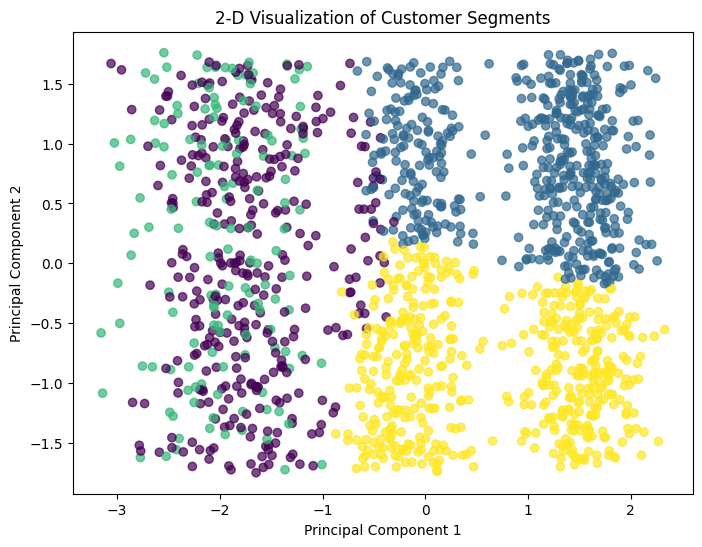

In [31]:
import matplotlib.pyplot as plt

# Preprocess the data using the existing pipeline
X_preprocessed = pipeline[:-2].fit_transform(df)

# Create 2-D PCA
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_preprocessed)

# Plot the segments
plt.figure(figsize=(8, 6))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=df["segment"],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2-D Visualization of Customer Segments")
plt.show()

Productionisation and Extension



In production, I would monitor changes in customer features such as monthly spend, orders, return rate, and tenure. I would also monitor cluster sizes and Silhouette Score. If feature distributions change significantly or clustering quality decreases, I would retrain the model using recent data.

To include product reviews, I would add their 384-dimensional text embeddings as numerical features along with the existing customer features. PCA can then reduce the combined dimensions before clustering.

A 2-D PCA visualization can show how well the segments are separated or overlapping. However, it cannot represent all information in the original high-dimensional data, so it should not be the only validation method.


### Appendix A: Dataset Generator for Section E

In [32]:
import numpy as np
import pandas as pd

def make_customers(n=1500, seed=42):

    rng = np.random.default_rng(seed)

    seg = rng.choice(4, size=n, p=[0.40, 0.30, 0.20, 0.10])

    spec = {
        0: (300, 6, 0.30),
        1: (900, 14, 0.10),
        2: (2500, 30, 0.05),
        3: (6000, 12, 0.02)
    }

    spend = np.array([
        max(5, rng.normal(spec[s][0], spec[s][0] * 0.25))
        for s in seg
    ])

    orders = np.array([
        max(1, rng.poisson(spec[s][1]))
        for s in seg
    ])

    ret = np.array([
        min(1, max(0, rng.normal(spec[s][2], 0.05)))
        for s in seg
    ])

    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "monthly_spend": spend.round(2),
        "orders_per_month": orders,
        "return_rate": ret.round(3),
        "tenure_months": rng.integers(1, 60, n),
        "preferred_channel": rng.choice(
            ["web", "app", "store"],
            n,
            p=[0.45, 0.40, 0.15]
        )
    })

    df.loc[
        rng.choice(n, 60, replace=False),
        "monthly_spend"
    ] = np.nan

    return df

In [33]:
df = make_customers()

print(df.head())
print("\nShape:", df.shape)

   customer_id  monthly_spend  orders_per_month  return_rate  tenure_months  \
0            1        3101.85                32        0.129             47   
1            2         736.96                17        0.121             26   
2            3        1966.40                26        0.031              4   
3            4        1003.43                15        0.107             22   
4            5         374.14                11        0.249              6   

  preferred_channel  
0               app  
1               app  
2             store  
3             store  
4               app  

Shape: (1500, 6)


### Conclusion

This assignment helped me understand the practical use of unsupervised learning for clustering and dimensionality reduction. I worked with K-Means, DBSCAN and PCA and learned how scaling, missing values, duplicate data, zero-variance features and different feature scales can affect the results. I also learned how to select and validate clusters using evaluation measures and stability checks.

The customer segmentation pipeline showed how preprocessing, encoding, scaling, PCA and clustering can be combined into one reproducible workflow. Overall, the assignment improved my understanding of handling real-world data, identifying edge cases, evaluating clustering results and using unsupervised learning for meaningful customer segmentation.